In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 4.0 MB/s eta 0:00:00


In [2]:
# Mount google drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Path of directory
drive_path = "/content/drive/MyDrive"
code_data_path = f"{drive_path}/master/mxene-solvent-nrc/code-data"
dataset_path = f"{code_data_path}/dataset"
model_path = f"{code_data_path}/training/saved_models"
current_path = f"{code_data_path}/training/final/polarity"

In [4]:
import pandas as pd
import numpy as np

# Load data
df_mx_solvent_data_labeled = pd.read_pickle(f"{dataset_path}/dataset_mx_additive_solvent_hsp.pkl")
df_mx_solvent_data_labeled.columns = df_mx_solvent_data_labeled.columns.str.lower()
print(df_mx_solvent_data_labeled.shape)
df_mx_solvent_data_labeled.head()

(3726, 80)


,mx,inchikey_additive,inchikey_solvent,label,gap_oh,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,...,heavy_atom_count_additive,isotope_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,solvent,additive,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,chloroform,dodecylphosphonic acid,False,False,True
1,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,ZSIAUFGUXNUGDI-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,hexan-1-ol,dodecylphosphonic acid,False,False,True
2,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WYURNTSHIVDZCO-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,oxolane,dodecylphosphonic acid,False,False,True
3,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,CSCPPACGZOOCGX-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,propan-2-one,dodecylphosphonic acid,False,False,True
4,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,...,16,0,0,0,1,acetonitrile,dodecylphosphonic acid,False,False,True


In [5]:
cols_to_keep = [col for col in df_mx_solvent_data_labeled.columns if not (df_mx_solvent_data_labeled[col].nunique() <= 1)]
df_mx_solvent_data_labeled = df_mx_solvent_data_labeled[cols_to_keep]

print(df_mx_solvent_data_labeled.shape)
df_mx_solvent_data_labeled.head()

(3726, 62)


,mx,inchikey_additive,inchikey_solvent,label,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,...,rotatable_bond_count_additive,heavy_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,solvent,additive,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,chloroform,dodecylphosphonic acid,False,False,True
1,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,ZSIAUFGUXNUGDI-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,hexan-1-ol,dodecylphosphonic acid,False,False,True
2,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WYURNTSHIVDZCO-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,oxolane,dodecylphosphonic acid,False,False,True
3,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,CSCPPACGZOOCGX-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,propan-2-one,dodecylphosphonic acid,False,False,True
4,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,acetonitrile,dodecylphosphonic acid,False,False,True


In [6]:
df_mx_solvent_data_labeled['method_hf'] = df_mx_solvent_data_labeled['method_hf'].astype('category').cat.codes
df_mx_solvent_data_labeled['method_licl/hf'] = df_mx_solvent_data_labeled['method_licl/hf'].astype('category').cat.codes
df_mx_solvent_data_labeled['method_lif/hcl'] = df_mx_solvent_data_labeled['method_lif/hcl'].astype('category').cat.codes

df_mx_solvent_data_labeled.head()

,mx,inchikey_additive,inchikey_solvent,label,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,...,rotatable_bond_count_additive,heavy_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,solvent,additive,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,chloroform,dodecylphosphonic acid,0,0,1
1,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,ZSIAUFGUXNUGDI-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,hexan-1-ol,dodecylphosphonic acid,0,0,1
2,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WYURNTSHIVDZCO-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,oxolane,dodecylphosphonic acid,0,0,1
3,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,CSCPPACGZOOCGX-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,propan-2-one,dodecylphosphonic acid,0,0,1
4,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,acetonitrile,dodecylphosphonic acid,0,0,1


In [7]:
df_mx_solvent_data_labeled.columns

Index(['mx', 'inchikey_additive', 'inchikey_solvent', 'label',
       'work_function_oh', 'formation_energy_oh', 'ehull_oh', 'alphax_el_oh',
       'alphay_el_oh', 'alphaz_el_oh', 'plasmafrequency_x_oh',
       'plasmafrequency_y_oh', 'has_inversion_symmetry_oh', 'gap_o',
       'work_function_o', 'formation_energy_o', 'ehull_o', 'alphax_el_o',
       'alphay_el_o', 'alphaz_el_o', 'plasmafrequency_x_o',
       'plasmafrequency_y_o', 'has_inversion_symmetry_o', 'work_function_f',
       'formation_energy_f', 'ehull_f', 'alphax_el_f', 'alphay_el_f',
       'alphaz_el_f', 'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume', 'molecular_weight', 'xlogp', 'tpsa', 'complexity',
       'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count',
       'heavy_atom_count', 'atom_stereo_count', 'boiling_point',
       'molecular_weight_additive', 'xlogp_additive', 'tpsa_additive',
       'complexity_add

In [8]:
features = ['work_function_oh', 'formation_energy_oh', 'ehull_oh', 'alphax_el_oh',
       'alphay_el_oh', 'alphaz_el_oh', 'plasmafrequency_x_oh',
       'plasmafrequency_y_oh', 'has_inversion_symmetry_oh', 'gap_o',
       'work_function_o', 'formation_energy_o', 'ehull_o', 'alphax_el_o',
       'alphay_el_o', 'alphaz_el_o', 'plasmafrequency_x_o',
       'plasmafrequency_y_o', 'has_inversion_symmetry_o', 'work_function_f',
       'formation_energy_f', 'ehull_f', 'alphax_el_f', 'alphay_el_f',
       'alphaz_el_f', 'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume',
       'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count', 'boiling_point', 'molecular_weight_additive',
       'xlogp_additive', 'tpsa_additive', 'complexity_additive',
       'h_bond_donor_count_additive', 'h_bond_acceptor_count_additive',
       'rotatable_bond_count_additive', 'heavy_atom_count_additive',
       'atom_stereo_count_additive', 'bond_stereo_count_additive',
       'covalent_unit_count_additive', 'method_hf',
       'method_licl/hf', 'method_lif/hcl']
X = df_mx_solvent_data_labeled[features]
y = df_mx_solvent_data_labeled['label']

In [9]:
X.loc[:, 'xlogp_additive'] = X['xlogp_additive'].fillna(X['xlogp_additive'].mean())

In [10]:
X.head()

,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,plasmafrequency_x_oh,plasmafrequency_y_oh,has_inversion_symmetry_oh,gap_o,...,h_bond_donor_count_additive,h_bond_acceptor_count_additive,rotatable_bond_count_additive,heavy_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,method_hf,method_licl/hf,method_lif/hcl
0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
2,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
3,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
4,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1


In [11]:
y.head()

,label
0,1
1,1
2,1
3,1
4,1


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
y.value_counts()

,count
label,
0,3665
1,56
-1,5


In [13]:
import xgboost as xgb

from sklearn.metrics import roc_auc_score, classification_report, f1_score
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def prepare_data(y, X, seed):
    # Get index for each label category
    positive_idx = np.where(y == 1)[0]
    unlabeled_idx = np.where(y == 0)[0]
    negative_idx = np.where(y == -1)[0]

    # Split positive samples to train/test
    pos_train_idx, pos_test_idx = train_test_split(
        positive_idx, test_size=0.2, random_state=seed
    )

    # Build training set: positive + unlabeled
    train_mask = np.zeros_like(y, dtype=bool)
    train_mask[pos_train_idx] = True
    train_mask[unlabeled_idx] = True
    X_train_full = X[train_mask]
    y_train_full = y[train_mask]

    # Training labels: positive 1, unlaebled 0
    y_train_pu = np.where(y_train_full == 1, 1, 0)

    # Build testing set: remained positive samples and all negative samples
    test_mask = np.zeros_like(y, dtype=bool)
    test_mask[pos_test_idx] = True
    test_mask[negative_idx] = True
    X_test = X[test_mask]
    y_test = np.where(y[test_mask] == 1, 1, 0)

    return X_train_full, y_train_pu, X_test, y_test

def objective(trial, X_train, y_train, X_val, y_val, seed):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'use_label_encoder': False,
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'random_state': seed,
        'verbosity': 0,
    }

    model = xgb.XGBClassifier(**param)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, pos_label=1)

def tune_hyperparameters(X_train, y_train, seed):
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=seed
    )
    study = optuna.create_study(direction='maximize', study_name='pu_learning_optuna', load_if_exists=True)
    study.optimize(lambda trial: objective(trial, X_train_split, y_train_split, X_val, y_val, seed), n_trials=30)
    best_params = study.best_params
    best_params.update({
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'use_label_encoder': False,
        'random_state': seed,
        'verbosity': 0,
    })
    return best_params

def train_and_predict(model_params, X_train, y_train, X_val, y_val, X_test):
    model = xgb.XGBClassifier(**model_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_test_pred = model.predict(X_test)
    return model, y_test_pred

In [15]:
X.head()

,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,plasmafrequency_x_oh,plasmafrequency_y_oh,has_inversion_symmetry_oh,gap_o,...,h_bond_donor_count_additive,h_bond_acceptor_count_additive,rotatable_bond_count_additive,heavy_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,method_hf,method_licl/hf,method_lif/hcl
0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
2,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
3,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1
4,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2,3,11,16,0,0,1,0,0,1


In [16]:
def coerce_numeric_columns(df: pd.DataFrame, cols):
    df = df.copy()
    for c in cols:
        if c not in df.columns:
            continue
        # convert to string, strip common junk, then to numeric
        s = (df[c].astype(str)
                 .str.replace(",", "", regex=False)
                 .str.replace("g/mol", "", regex=False)
                 .str.replace("G/mol", "", regex=False)
                 .str.strip())
        df[c] = pd.to_numeric(s, errors="coerce")
    return df

mw_cols = ["molecular_weight", "molecular_weight_additive"]
X = coerce_numeric_columns(X, mw_cols)

In [18]:
# Training and predicting

#========== Description ==========
# 1. Conditions for training the best model:
#    (1) Force training: set "retraining_best_model = True";
#    (2) Or, best model file does not exist
#    (2) Or, best params file does not exist
# 2. Each epoch of training - the outer loop
#    (1) Set an unique random state seed for each epoch
#    (2) Split the whole datasets (X_scaled and y) to train/test
#        (a) split all positive samples: positive train samples, positive test samples
#        (b) build full train samples: positive train samples + all unlabeled samples
#        (c) build test samples: positive test samples + all negative samples
#        (d) NOTE: The full train and test datasets should be different among epoches
#    (3) Run some iterations to find the best model, best params, and best classification report for each epoach
#    (4) Update the final best model, final best params, and final best classification report
# 3. Each iteration - the inner loop
#    (1) Split the full train samples: train samples, val samples
#    (2) Find the best params according to the given tune interval (every 5 iterations)
#    (3) Train and val:
#        (a) find current positive f1, current classification report
#        (b) select unlabeled samples from the full train dataset with the give top k probability
#            - update these samples as new positive samples
#            - NOTE: the full train samples are updated and shuffled within each iteration
#            - NOTE: the number of unleabled samples decrease after an iteration
#    (4) Update the best model, best params, and best classification report of current epoch
#    (5) Early stopping
# 4. Save the final best model, final best params

import os
import json

best_model_path = f"{model_path}/best_model_final_hsp_007_1.json"
best_params_path = f"{model_path}/best_params_final_hsp_007_1.json"

retraining_best_model = False
best_model_exists = os.path.exists(best_model_path)
best_params_exists = os.path.exists(best_params_path)

if best_model_exists and best_params_exists and not retraining_best_model:
    print("Loading best model...")

    best_model = xgb.XGBClassifier()
    best_model.load_model(best_model_path)

    with open(best_params_path, 'r', encoding='utf-8') as f:
        best_params = json.load(f)

else:
    print("Training best model...")

    num_epoch = 5

    final_best_pos_f1 = 0
    final_best_model = None
    final_best_params = None

    final_best_report = None
    final_best_epoch = 0
    final_best_iter = 0

    for epoch in range(num_epoch):
        print(f"==== Epoch {epoch+1} ====")

        seed = 42 + epoch

        X_train_full, y_train_pu, X_test, y_test = prepare_data(y, X, seed)
        X_train_full = np.asarray(X_train_full, dtype=np.float32)
        X_test = np.asarray(X_test, dtype=np.float32)
        y_train_pu = np.asarray(y_train_pu)
        y_test = np.asarray(y_test)

        num_iterations = 500
        tune_interval = 5

        early_stopping_rounds = 20
        no_improve_rounds = 0

        best_iter = 0
        best_pos_f1 = 0
        best_model = None
        best_params = None
        best_report = None

        for iter in range(num_iterations):
            print(f"==== Iteration {iter+1} ====")

            # Dynamic top fraction of unlabeled probabilities
            if iter < 5:
                top_fraction = 0.01
            elif iter < 10:
                top_fraction = 0.006
            else:
                top_fraction = 0.003

            # Split training set to train/val
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_full, y_train_pu, test_size=0.2, stratify=y_train_pu, random_state=seed
            )

            # Fine tune hyperparameters
            if iter == 0 or (iter % tune_interval == 0):
                best_params = tune_hyperparameters(X_train, y_train, seed)
                print("Best params:", best_params)

            # Training and validating
            model, y_test_pred = train_and_predict(best_params, X_train, y_train, X_val, y_val, X_test)

            # Calculate positive f1 score
            pos_f1 = f1_score(y_test, y_test_pred, pos_label=1)
            print(f"Iter {iter + 1}, Positive F1: {pos_f1:.4f}")
            current_report = classification_report(y_test, y_test_pred, zero_division=0)

            # Find positive samples with high confidence from unlabeled samples
            unlabeled_mask = (y_train_pu == 0)
            if not np.any(unlabeled_mask):
                print("No unlabeled samples left.")
                break

            X_unlabeled = X_train_full[unlabeled_mask]
            proba_unlabeled = model.predict_proba(X_unlabeled)[:, 1]
            top_k = max(1, int(len(proba_unlabeled) * top_fraction))
            confident_pos_idx = np.argsort(proba_unlabeled)[-top_k:]

            # Select at most half unlabeled samples as positive samples
            if len(confident_pos_idx) > 0.5 * len(X_unlabeled):
                confident_pos_idx = confident_pos_idx[:int(0.5 * len(X_unlabeled))]
            print(f"Unlabeled samples: {len(X_unlabeled)}, confident positive found: {len(confident_pos_idx)}")

            # Remained unlabeled samples
            keep_unlabeled_mask = np.ones(len(X_unlabeled), dtype=bool)
            keep_unlabeled_mask[confident_pos_idx] = False

            # Build a new full training set: old positive, new positive, unlabeled
            X_pos = X_train_full[y_train_pu == 1]
            y_pos = np.ones(len(X_pos))

            X_new_pos = X_unlabeled[confident_pos_idx]
            y_new_pos = np.ones(len(X_new_pos))

            X_unlabeled_remain = X_unlabeled[keep_unlabeled_mask]
            y_unlabeled_remain = np.zeros(len(X_unlabeled_remain))

            X_train_full = np.vstack([X_pos, X_new_pos, X_unlabeled_remain])
            y_train_pu = np.concatenate([y_pos, y_new_pos, y_unlabeled_remain])

            # Shuffle the new full training set
            perm = np.random.permutation(len(X_train_full))
            X_train_full = X_train_full[perm]
            y_train_pu = y_train_pu[perm]

            # Update the best model
            if pos_f1 < 1 and pos_f1 > best_pos_f1:
                no_improve_rounds = 0

                best_pos_f1 = pos_f1
                best_model = model
                best_iter = iter + 1
                best_report = current_report

                print("Best Test report:")
                print(best_report)
                print("Best Positive F1:", best_pos_f1)
            else:
                no_improve_rounds += 1

            print()

            # Early stopping
            if no_improve_rounds >= early_stopping_rounds:
                print(f"Early stopping at iteration {iter + 1}, best iteration was {best_iter} with Positive F1={best_pos_f1:.4f}")
                print()
                break

        # Update the final best model
        if final_best_pos_f1 < best_pos_f1:
            final_best_pos_f1 = best_pos_f1
            final_best_model = best_model
            final_best_params = best_params
            final_best_iter = best_iter
            final_best_epoch = epoch + 1
            final_best_report = best_report

    print("Final best Positive F1:", final_best_pos_f1)
    print("Final best iteration:", final_best_iter)
    print("Final best epoch:", final_best_epoch)
    print("Final best report:", final_best_report)

    # Save the final best model and best params to files
    final_best_model.save_model(best_model_path)
    with open(best_params_path, 'w', encoding='utf-8') as f:
        json.dump(final_best_params, f, ensure_ascii=False, indent=2)
    print("Best model and params saved.")
    print("Final training done.")

Training best model...
==== Epoch 1 ====
==== Iteration 1 ====
Best params: {'max_depth': 6, 'learning_rate': 0.09269525924099539, 'subsample': 0.7545829806250948, 'colsample_bytree': 0.6993013354287545, 'n_estimators': 365, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'use_label_encoder': False, 'random_state': 42, 'verbosity': 0}
Iter 1, Positive F1: 0.4000
Unlabeled samples: 3665, confident positive found: 36
Best Test report:
              precision    recall  f1-score   support

           0       0.36      1.00      0.53         5
           1       1.00      0.25      0.40        12

    accuracy                           0.47        17
   macro avg       0.68      0.62      0.46        17
weighted avg       0.81      0.47      0.44        17

Best Positive F1: 0.4

==== Iteration 2 ====
Iter 2, Positive F1: 0.6316
Unlabeled samples: 3629, confident positive found: 36
Best Test report:
              precision    recall  f1-score   support

           0       0.40      0

In [19]:
positive_idx = np.where(y == 1)[0]
unlabeled_idx = np.where(y == 0)[0]
negative_idx = np.where(y == -1)[0]

test_mask = np.zeros_like(y, dtype=bool)
test_mask[positive_idx] = True
test_mask[negative_idx] = True
X_test = X[test_mask]
y_test = np.where(y[test_mask] == 1, 1, 0)

X_unlabeled = X[y == 0]
df_unlabeled = df_mx_solvent_data_labeled[y == 0].copy()

In [20]:
print(df_unlabeled.shape)
df_unlabeled.head()

(3665, 62)


,mx,inchikey_additive,inchikey_solvent,label,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,...,rotatable_bond_count_additive,heavy_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,solvent,additive,method_hf,method_licl/hf,method_lif/hcl
61,Ti3C2,QLZHNIAADXEJJP-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,10,0,0,1,chloroform,phenylphosphonic acid,0,0,1
62,Ti3C2,AEYNBBVVVQOVIT-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,9,29,1,0,1,chloroform,"3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...",0,0,1
63,Ti3C2,CBSOFSBFHDQRLV-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,2,10,0,0,2,chloroform,benzyl(methyl)azanium;chloride,0,0,1
64,Ti3C2,QGLWBTPVKHMVHM-KTKRTIGZSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,15,19,0,1,1,chloroform,(Z)-octadec-9-en-1-amine,0,0,1
65,Ti3C2,ZAZSHMPSDGNFLA-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,8,12,0,0,1,chloroform,5-(2-methoxyethoxy)pentanoic acid,0,0,1


In [21]:
final_best_model = best_model

In [22]:
# Result of the final best model on labeled samples
y_test_pred = final_best_model.predict(X_test)

print("Test result on labeled samples:")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("Test ROC AUC Score:", roc_auc_score(y_test, y_test_pred))
print()

Test result on labeled samples:
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.93      1.00      0.97        56

    accuracy                           0.93        61
   macro avg       0.97      0.60      0.65        61
weighted avg       0.94      0.93      0.91        61

Test ROC AUC Score: 0.6



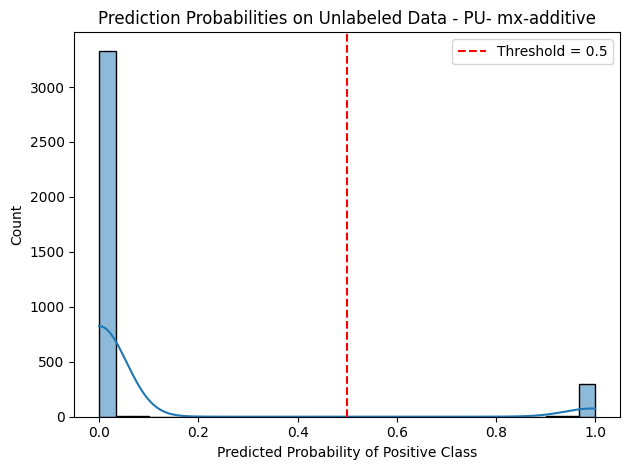

In [26]:
# Predict unlabeled samples
proba_unlabeled = final_best_model.predict_proba(X_unlabeled)[:, 1]
df_unlabeled['predicted_proba'] = proba_unlabeled
df_unlabeled['predicted_label'] = (proba_unlabeled >= 0.5).astype(int)

sns.histplot(proba_unlabeled, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Prediction Probabilities on Unlabeled Data - PU- mx-additive")
plt.xlabel("Predicted Probability of Positive Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
unlabeled_proba_threshold = 0.5
high_confidence_pos_idx = np.where(proba_unlabeled > unlabeled_proba_threshold)[0]
print(f"Positive samples above threshold ({unlabeled_proba_threshold}) count: {len(high_confidence_pos_idx)}")

Positive samples above threshold (0.5) count: 318


In [28]:
high_conf = df_unlabeled[df_unlabeled['predicted_proba'] >= 0.9]
high_conf = high_conf[high_conf['predicted_proba'] < 0.99]
top_list = high_conf.sort_values(by='predicted_proba', ascending=False)
print(top_list.shape)
top_list[['solvent', 'mx', 'additive','predicted_proba', 'method_lif/hcl', 'method_licl/hf', 'method_hf']]

(66, 64)


,solvent,mx,additive,predicted_proba,method_lif/hcl,method_licl/hf,method_hf
394,hexane,Ti3C2,5-(2-methoxyethoxy)pentanoic acid,0.989578,0,0,1
236,prop-2-enenitrile,Ti3C2,5-(2-methoxyethoxy)pentanoic acid,0.989363,1,0,0
233,prop-2-enenitrile,Ti3C2,"3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...",0.989303,1,0,0
268,propan-2-one,Ti3C2,"3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...",0.989253,0,0,1
185,oxidane,Ti3C2,"propane-1,2-diol",0.988171,1,0,0
...,...,...,...,...,...,...,...
530,"4-methyl-1,3-dioxolan-2-one",Ti3C2,(Z)-octadec-9-en-1-amine,0.938586,0,1,0
468,propan-2-one,Ti3C2,phenylphosphonic acid,0.934033,0,1,0
91,acetonitrile,Ti3C2,benzyl(methyl)azanium;chloride,0.927365,1,0,0
331,"4-methyl-1,3-dioxolan-2-one",Ti3C2,(Z)-octadec-9-en-1-amine,0.926083,0,0,1


In [29]:
print("\n=== Summary of predicted probabilities on unlabeled data ===")
print(df_unlabeled['predicted_proba'].describe())

# Count how many samples fall into different confidence zones
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['Very Low (≤0.1)', 'Low (0.1–0.3)', 'Mid (0.3–0.5)',
          'High (0.5–0.7)', 'Very High (0.7–0.9)', 'Extremely High (>0.9)']

df_unlabeled['confidence_bin'] = pd.cut(df_unlabeled['predicted_proba'], bins=bins, labels=labels, include_lowest=True)
print("\n=== Prediction count by confidence bin ===")
print(df_unlabeled['confidence_bin'].value_counts().sort_index())


=== Summary of predicted probabilities on unlabeled data ===
count    3.665000e+03
mean     8.652540e-02
std      2.778176e-01
min      1.624790e-07
25%      7.574272e-06
50%      1.198556e-04
75%      7.080704e-04
max      9.999961e-01
Name: predicted_proba, dtype: float64

=== Prediction count by confidence bin ===
confidence_bin
Very Low (≤0.1)          3343
Low (0.1–0.3)               4
Mid (0.3–0.5)               0
High (0.5–0.7)              4
Very High (0.7–0.9)         4
Extremely High (>0.9)     310
Name: count, dtype: int64


In [30]:
train_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/training/final/hsp/"

In [31]:
df_unlabeled.to_csv(f"{train_path}/007_p_vs_n_predictions_unlabeled_hsp_xg-normalize-fintune-mxadd.csv")
df_unlabeled.to_pickle(f"{train_path}/007_p_vs_n_predictions_unlabeled_hsp_xg-normalize-fintune-mxadd.pkl")


                           feature  importance
6             plasmafrequency_x_oh    0.303840
7             plasmafrequency_y_oh    0.269879
49       heavy_atom_count_additive    0.067631
43                  xlogp_additive    0.066277
30                         delta_h    0.056736
34                            tpsa    0.027802
51      bond_stereo_count_additive    0.025219
55                  method_lif/hcl    0.024773
44                   tpsa_additive    0.023988
42       molecular_weight_additive    0.022759
37           h_bond_acceptor_count    0.018883
35                      complexity    0.018396
8        has_inversion_symmetry_oh    0.011448
33                           xlogp    0.008877
41                   boiling_point    0.008249
31                    molar_volume    0.008230
29                         delta_p    0.006538
45             complexity_additive    0.004964
53                       method_hf    0.003793
36              h_bond_donor_count    0.003344
32           

/tmp/ipython-input-3418997240.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature',


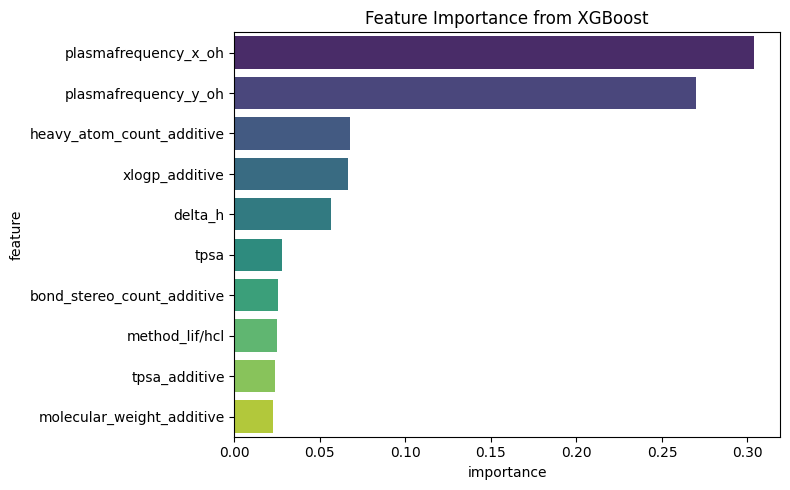

In [32]:
feature_names = X.columns

# After training
importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature',
            data=feature_importance_df.head(10),
            palette='viridis')
plt.title('Feature Importance from XGBoost')
plt.tight_layout()
plt.show()

In [33]:
mx_features = ['work_function_oh', 'formation_energy_oh', 'ehull_oh', 'alphax_el_oh',
       'alphay_el_oh', 'alphaz_el_oh', 'plasmafrequency_x_oh',
       'plasmafrequency_y_oh', 'has_inversion_symmetry_oh', 'gap_o',
       'work_function_o', 'formation_energy_o', 'ehull_o', 'alphax_el_o',
       'alphay_el_o', 'alphaz_el_o', 'plasmafrequency_x_o',
       'plasmafrequency_y_o', 'has_inversion_symmetry_o', 'work_function_f',
       'formation_energy_f', 'ehull_f', 'alphax_el_f', 'alphay_el_f',
       'alphaz_el_f', 'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f']
solv_features = ['delta_d', 'delta_p', 'delta_h',
       'molar_volume',
       'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count', 'boiling_point']
add_features = ['molecular_weight_additive',
       'xlogp_additive', 'tpsa_additive', 'complexity_additive',
       'h_bond_donor_count_additive', 'h_bond_acceptor_count_additive',
       'rotatable_bond_count_additive', 'heavy_atom_count_additive',
       'atom_stereo_count_additive', 'bond_stereo_count_additive',
       'covalent_unit_count_additive']


In [34]:
top_mx = feature_importance_df[feature_importance_df['feature'].isin(mx_features)] \
            .sort_values(by='importance', ascending=False) \
            .head(5)

# Top 5 from Solvent features
top_solv = feature_importance_df[feature_importance_df['feature'].isin(solv_features)] \
              .sort_values(by='importance', ascending=False) \
              .head(5)

top_add = feature_importance_df[feature_importance_df['feature'].isin(add_features)] \
              .sort_values(by='importance', ascending=False) \
              .head(5)

# Display
print("Total  MXene Features:", len(mx_features))
print("Top 5 MXene Features:")
print(top_mx.to_string(index=False))

print("\nTotal  Solvent Features:", len(solv_features))
print("Top 5 Solvent Features:")
print(top_solv.to_string(index=False))

print("\nTotal  Additive Features:", len(add_features))
print("Top 5 Additive Features:")
print(top_add.to_string(index=False))

Total  MXene Features: 28
Top 5 MXene Features:
                  feature  importance
     plasmafrequency_x_oh    0.303840
     plasmafrequency_y_oh    0.269879
has_inversion_symmetry_oh    0.011448
      plasmafrequency_y_f    0.002607
 has_inversion_symmetry_o    0.001492

Total  Solvent Features: 14
Top 5 Solvent Features:
              feature  importance
              delta_h    0.056736
                 tpsa    0.027802
h_bond_acceptor_count    0.018883
           complexity    0.018396
                xlogp    0.008877

Total  Additive Features: 11
Top 5 Additive Features:
                   feature  importance
 heavy_atom_count_additive    0.067631
            xlogp_additive    0.066277
bond_stereo_count_additive    0.025219
             tpsa_additive    0.023988
 molecular_weight_additive    0.022759


In [35]:
df_train = df_mx_solvent_data_labeled[y == 1].copy()
df_train

,mx,inchikey_additive,inchikey_solvent,label,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,...,rotatable_bond_count_additive,heavy_atom_count_additive,atom_stereo_count_additive,bond_stereo_count_additive,covalent_unit_count_additive,solvent,additive,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,HEDRZPFGACZZDS-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,chloroform,dodecylphosphonic acid,0,0,1
1,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,ZSIAUFGUXNUGDI-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,hexan-1-ol,dodecylphosphonic acid,0,0,1
2,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WYURNTSHIVDZCO-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,oxolane,dodecylphosphonic acid,0,0,1
3,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,CSCPPACGZOOCGX-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,propan-2-one,dodecylphosphonic acid,0,0,1
4,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,acetonitrile,dodecylphosphonic acid,0,0,1
5,Ti3C2,SVMUEEINWGBIPD-UHFFFAOYSA-N,KFZMGEQAYNKOFK-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,11,16,0,0,1,propan-2-ol,dodecylphosphonic acid,0,0,1
6,Ti3C2,QLZHNIAADXEJJP-UHFFFAOYSA-N,XEKOWRVHYACXOJ-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,10,0,0,1,ethyl acetate,phenylphosphonic acid,0,0,1
7,Ti3C2,QLZHNIAADXEJJP-UHFFFAOYSA-N,YMWUJEATGCHHMB-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,10,0,0,1,dichloromethane,phenylphosphonic acid,0,0,1
8,Ti3C2,QLZHNIAADXEJJP-UHFFFAOYSA-N,KXKVLQRXCPHEJC-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,10,0,0,1,methyl acetate,phenylphosphonic acid,0,0,1
9,Ti3C2,QLZHNIAADXEJJP-UHFFFAOYSA-N,MRABAEUHTLLEML-UHFFFAOYSA-N,1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,10,0,0,1,butyl 2-hydroxypropanoate,phenylphosphonic acid,0,0,1


In [36]:
X_labeled = X[y == 1]

In [37]:
proba_train = best_model.predict_proba(X_labeled)[:, 1]

df_train['predicted_proba'] = proba_train
df_train['predicted_label'] = (proba_train >= 0.5).astype(int)

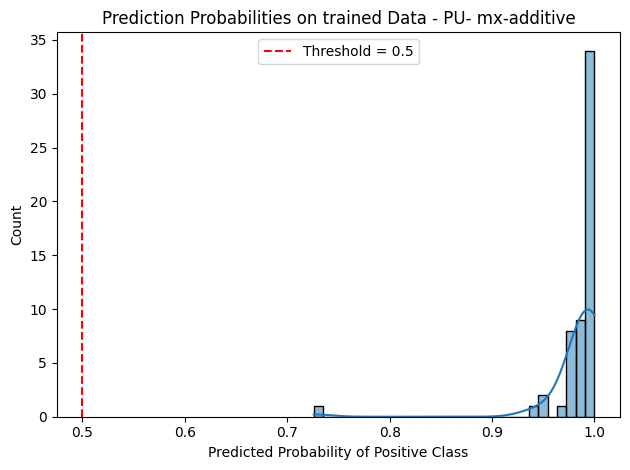

In [38]:
sns.histplot(proba_train, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Prediction Probabilities on trained Data - PU- mx-additive")
plt.xlabel("Predicted Probability of Positive Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
top_solvents_test = ( df_unlabeled.loc[df_unlabeled.groupby("mx")["predicted_proba"].idxmax(), ["mx", "solvent", "predicted_proba", "additive"]] .reset_index(drop=True) )
print(top_solvents_test)

      mx  solvent  predicted_proba  \
0  Mo2C1  oxidane         0.995990   
1  Nb2C1  oxidane         0.995990   
2  Ti2C1  oxidane         0.995990   
3  Ti3C2  oxidane         0.999996   
4  Ti4N3  oxidane         0.995990   
5   V2C1  oxidane         0.995990   

                                            additive  
0  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...  
1  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...  
2  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...  
3  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...  
4  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...  
5  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...  


In [40]:
import pandas as pd

# Assuming df has columns: ['mx', 'solvent', 'probability']
top_solvents_test2 = (
    df_unlabeled
    .query("predicted_proba < 0.999")   # 👈 filter high-confidence ones out
    .query("predicted_proba > 0.5")
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent", "additive"])
    .groupby("mx")
    .head(20)
    [
        ["mx", "solvent", "additive", "predicted_proba",
         "method_lif/hcl", "method_licl/hf", "method_hf"]
    ]
    .reset_index(drop=True)
)

print(top_solvents_test2)

       mx          solvent                                           additive  \
0   Ti3C2  dichloromethane  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
1   Ti3C2       hexan-1-ol  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
2   Ti3C2          ethanol                             dodecylphosphonic acid   
3   Ti3C2         methanol                             dodecylphosphonic acid   
4   Ti3C2      propan-2-ol                              phenylphosphonic acid   
5   Ti3C2      propan-2-ol                             dodecylphosphonic acid   
6   Ti3C2  dichloromethane                              phenylphosphonic acid   
7   Ti3C2       hexan-1-ol                             dodecylphosphonic acid   
8   Ti3C2          oxolane                  5-(2-methoxyethoxy)pentanoic acid   
9   Ti3C2          ethanol                              phenylphosphonic acid   
10  Ti3C2         methanol                              phenylphosphonic acid   
11  Ti3C2  dichloromethane  

In [41]:
green_solvents = [
    "oxidane",
    "ethanol",
    "propan-2-ol",
    "ethyl acetate",
    "methyl acetate"
]

top_solvents_testgreen = (
    df_unlabeled
    .query("predicted_proba < 0.999")
    .query("predicted_proba > 0.5")
    .query("solvent in @green_solvents")   # 👈 GREEN FILTER HERE
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent", "additive"])
    .groupby("mx")
    .head(20)
    [
        ["mx", "solvent", "additive", "predicted_proba",
         "method_lif/hcl", "method_licl/hf", "method_hf"]
    ]
    .reset_index(drop=True)
)

print(top_solvents_testgreen)

       mx         solvent                                           additive  \
0   Ti3C2         ethanol                             dodecylphosphonic acid   
1   Ti3C2     propan-2-ol                              phenylphosphonic acid   
2   Ti3C2     propan-2-ol                             dodecylphosphonic acid   
3   Ti3C2         ethanol                              phenylphosphonic acid   
4   Ti3C2     propan-2-ol                     benzyl(methyl)azanium;chloride   
5   Ti3C2         ethanol                     benzyl(methyl)azanium;chloride   
6   Ti3C2         ethanol                  5-(2-methoxyethoxy)pentanoic acid   
7   Ti2C1         oxidane  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
8   Nb2C1         oxidane  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
9    V2C1         oxidane  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
10  Ti4N3         oxidane  3,3,4,4,5,5,6,6,6-nonafluorohexyl 2-amino-3-(3...   
11  Mo2C1         oxidane  3,3,4,4,5,5,6

In [42]:
import pandas as pd

# Assuming df has columns: ['mx', 'solvent', 'probability']
top_solvents = (
    df_train
    .query("predicted_proba < 0.999")   # 👈 filter high-confidence ones out
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent", "additive"])
    .groupby("mx")
    .head(20)
    [
        ["mx", "solvent", "additive", "predicted_proba",
         "method_lif/hcl", "method_licl/hf", "method_hf"]
    ]
    .reset_index(drop=True)
)

print(top_solvents)

       mx                                     solvent  \
0   Ti3C2                                acetonitrile   
1   Ti3C2                                acetonitrile   
2   Mo2C1                                     ethanol   
3   Nb2C1                                     ethanol   
4   Ti4N3                                     ethanol   
5    V2C1                                     ethanol   
6   Ti2C1                                     ethanol   
7   Ti3C2                                 cyclohexane   
8   Ti3C2                       methylsulfinylmethane   
9   Ti3C2                       methylsulfinylmethane   
10  Ti3C2                       methylsulfinylmethane   
11  Ti3C2                                  chloroform   
12  Ti3C2                             dichloromethane   
13  Ti3C2                                    methanol   
14  Ti3C2                    1-methylpyrrolidin-2-one   
15  Ti3C2                       N,N-dimethylformamide   
16  Ti3C2                    1-

In [43]:
top_solvents2 = (
    df_train
    .query("predicted_proba < 0.99")   # 👈 filter high-confidence ones out
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent", "additive"])
    .groupby("mx")
    .head(20)
    [
        ["mx", "solvent", "additive", "predicted_proba",
         "method_lif/hcl", "method_licl/hf", "method_hf"]
    ]
    .reset_index(drop=True)
)

print(top_solvents2)

       mx                                     solvent  \
0   Ti3C2                                  chloroform   
1   Ti3C2                             dichloromethane   
2   Ti3C2                                    methanol   
3   Ti3C2                    1-methylpyrrolidin-2-one   
4   Ti3C2                       N,N-dimethylformamide   
5   Ti3C2                    1-methylpyrrolidin-2-one   
6   Ti3C2                              methyl acetate   
7   Ti3C2                                  1,4-xylene   
8   Ti3C2                                     oxidane   
9   Ti3C2                                     oxidane   
10  Ti3C2                                     oxidane   
11  Ti3C2  1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene   
12  Ti3C2                               ethyl acetate   
13  Ti3C2                    1-methylpyrrolidin-2-one   
14  Ti3C2                               ethyl acetate   
15  Ti3C2                       N,N-dimethylformamide   
16  Ti3C2                      

In [44]:
unique_solvents = df_unlabeled["solvent"].unique()
print(unique_solvents)

['chloroform' 'hexan-1-ol' 'oxolane' 'propan-2-one' 'acetonitrile'
 'propan-2-ol' 'ethyl acetate' 'dichloromethane' 'methyl acetate'
 'butyl 2-hydroxypropanoate' '4-methyl-1,3-dioxolan-2-one' 'ethanol'
 'methanol' '1-methylpyrrolidin-2-one' 'methylsulfinylmethane'
 'N,N-dimethylformamide' 'oxidane' 'hexane' 'cyclohexane' 'toluene'
 '1,4-xylene' '1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene'
 'prop-2-enenitrile']


In [45]:
acceptable_solvents = [
    "methanol",
    "acetonitrile",
    "oxolane",
    "hexan-1-ol",
    "4-methyl-1,3-dioxolan-2-one",
    "1-methylpyrrolidin-2-one",
    "methylsulfinylmethane",
    "butyl 2-hydroxypropanoate",
    "cyclohexane"
]

top_solvents_test2_acceptable = (
    df_unlabeled
    .query("predicted_proba < 0.999")
    .query("predicted_proba > 0.5")
    .query("solvent in @acceptable_solvents")   # 👈 ACCEPTABLE FILTER
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent", "additive"])
    .groupby("mx")
    .head(20)
    [
        ["mx", "solvent", "additive", "predicted_proba",
         "method_lif/hcl", "method_licl/hf", "method_hf"]
    ]
    .reset_index(drop=True)
)

print(top_solvents_test2_acceptable)

       mx                   solvent  \
0   Ti3C2                hexan-1-ol   
1   Ti3C2                  methanol   
2   Ti3C2                hexan-1-ol   
3   Ti3C2                   oxolane   
4   Ti3C2                  methanol   
5   Ti3C2                hexan-1-ol   
6   Ti3C2                   oxolane   
7   Ti3C2               cyclohexane   
8   Ti3C2                  methanol   
9    V2C1                  methanol   
10  Ti2C1                  methanol   
11  Mo2C1                  methanol   
12  Ti4N3                  methanol   
13  Nb2C1                  methanol   
14  Ti3C2              acetonitrile   
15  Ti3C2     methylsulfinylmethane   
16  Ti3C2               cyclohexane   
17  Ti3C2                   oxolane   
18  Ti3C2     methylsulfinylmethane   
19  Ti3C2  1-methylpyrrolidin-2-one   
20  Ti3C2                hexan-1-ol   
21  Ti3C2                  methanol   
22  Ti3C2              acetonitrile   
23  Ti3C2                   oxolane   
24  Ti3C2                